# Hazardous Asteroid Prediction

This notebook implements a complete machine learning workflow for classifying Near-Earth Objects (NEOs) as hazardous or non-hazardous.
The project follows the NASA assignment across preprocessing, EDA, feature engineering, modeling, explainability, and deployment.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')


Libraries imported successfully.


## Phase 1: Data Preparation and Preprocessing

Load the NASA NEO dataset, inspect the schema, and prepare the features and target for modeling.


In [2]:
data_dir = Path.cwd()
candidate_files = list(data_dir.glob('neo*.csv'))
if not candidate_files:
    raise FileNotFoundError('No asteroid CSV file was found in the current working directory.')

data_path = candidate_files[0]
df = pd.read_csv(data_path)
print(f'Dataset path: {data_path}')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()


Dataset path: c:\Users\User\Desktop\PRojects\neo (3) (2).csv
Dataset shape: (90836, 10)
Columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [3]:
df['hazardous'] = df['hazardous'].astype(bool).astype(int)
df['avg_diameter'] = (df['est_diameter_min'] + df['est_diameter_max']) / 2

print(df.isna().sum().to_string())
print(f'Class balance: {df['hazardous'].value_counts().to_dict()}')


id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
avg_diameter          0
Class balance: {0: 81996, 1: 8840}


## Phase 2: Exploratory Data Analysis

Inspect the class distribution and key asteroid patterns that relate to hazardous objects.


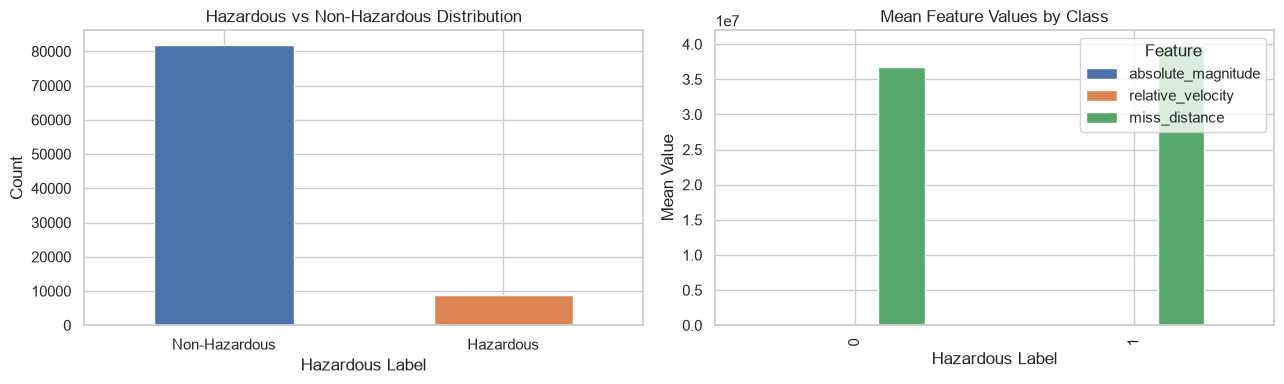

hazardous                            0             1
absolute_magnitude count  8.199600e+04  8.840000e+03
                   mean   2.387420e+01  2.030760e+01
                   std    2.801199e+00  1.341676e+00
                   min    9.230000e+00  1.404000e+01
                   25%    2.206000e+01  1.960775e+01
                   50%    2.410000e+01  2.060000e+01
                   75%    2.590000e+01  2.136000e+01
                   max    3.320000e+01  2.240000e+01
relative_velocity  count  8.199600e+04  8.840000e+03
                   mean   4.647915e+04  6.279434e+04
                   std    2.456033e+04  2.717511e+04
                   min    2.033464e+02  5.908292e+03
                   25%    2.763601e+04  4.301781e+04
                   50%    4.256550e+04  5.865801e+04
                   75%    6.106240e+04  7.878582e+04
                   max    2.369901e+05  1.933870e+05
miss_distance      count  8.199600e+04  8.840000e+03
                   mean   3.675609e+07  3.994623e+07
                   std    2.245904e+07  2.111883e+07
                   min    6.745533e+03  1.432727e+05
                   25%    1.672851e+07  2.172841e+07
                   50%    3.748745e+07  4.098372e+07
                   75%    5.628455e+07  5.852393e+07
                   max    7.479865e+07  7.479095e+07

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

target_counts = df['hazardous'].value_counts().sort_index()
target_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Hazardous vs Non-Hazardous Distribution')
axes[0].set_xlabel('Hazardous Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Hazardous', 'Hazardous'], rotation=0)

group_means = df.groupby('hazardous')[['absolute_magnitude', 'relative_velocity', 'miss_distance']].mean()
group_means.plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Feature Values by Class')
axes[1].set_xlabel('Hazardous Label')
axes[1].set_ylabel('Mean Value')
axes[1].legend(title='Feature')

plt.tight_layout()
plt.show()

df[['absolute_magnitude', 'relative_velocity', 'miss_distance', 'hazardous']].groupby('hazardous').describe().T


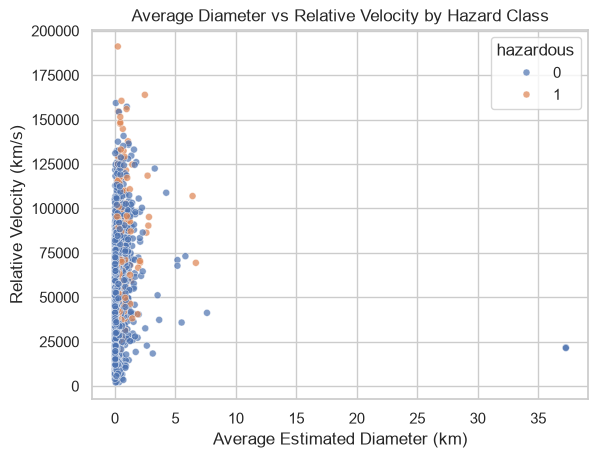

In [5]:
sample = df.sample(4000, random_state=42)
sns.scatterplot(
    data=sample,
    x='avg_diameter',
    y='relative_velocity',
    hue='hazardous',
    palette={0: '#4C72B0', 1: '#DD8452'},
    alpha=0.7,
    s=25,
)
plt.title('Average Diameter vs Relative Velocity by Hazard Class')
plt.xlabel('Average Estimated Diameter (km)')
plt.ylabel('Relative Velocity (km/s)')
plt.show()


## Phase 3: Feature Engineering and Selection

Keep the informative predictors, remove identifiers, and check the feature relationships before model training.


In [6]:
drop_columns = ['id', 'name']
X = df.drop(columns=['hazardous', *drop_columns])
y = df['hazardous']

print('Feature columns:', list(X.columns))
print(f'Input shape: {X.shape}')

corr = X.select_dtypes(include=['number']).corr(numeric_only=True)
corr.head()


Feature columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'avg_diameter']
Input shape: (90836, 8)


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,avg_diameter
est_diameter_min,1.000000,1.000000,0.221553,0.142241,-0.560188,1.000000
est_diameter_max,1.000000,1.000000,0.221553,0.142241,-0.560188,1.000000
relative_velocity,0.221553,0.221553,1.000000,0.327169,-0.353863,0.221553
miss_distance,0.142241,0.142241,0.327169,1.000000,-0.264168,0.142241
absolute_magnitude,-0.560188,-0.560188,-0.353863,-0.264168,1.000000,-0.560188


## Phase 4: Model Development

Split the data into train and test sets and compare candidate supervised classification models.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = ['orbiting_body']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            'cat',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder='drop',
)

logistic_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=3000,
    solver='liblinear',
)

rf_model = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    class_weight='balanced',
    min_samples_leaf=5,
    n_jobs=-1,
)

models = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor), ('model', logistic_model)]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('model', rf_model)]),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob),
        'Average Precision': average_precision_score(y_test, y_prob),
    })

    print(f'\n{name}')
    print(classification_report(y_test, y_pred, target_names=['Non-Hazardous', 'Hazardous']))
    print(f'Confusion matrix:\n{confusion_matrix(y_test, y_pred)}')

pd.DataFrame(results).sort_values('F1 Score', ascending=False)



Logistic Regression
               precision    recall  f1-score   support

Non-Hazardous       0.99      0.77      0.87     16400
    Hazardous       0.30      0.93      0.46      1768

     accuracy                           0.79     18168
    macro avg       0.65      0.85      0.66     18168
 weighted avg       0.92      0.79      0.83     18168

Confusion matrix:
[[12631  3769]
 [  120  1648]]

Random Forest
               precision    recall  f1-score   support

Non-Hazardous       0.99      0.83      0.91     16400
    Hazardous       0.38      0.93      0.54      1768

     accuracy                           0.84     18168
    macro avg       0.68      0.88      0.72     18168
 weighted avg       0.93      0.84      0.87     18168

Confusion matrix:
[[13654  2746]
 [  119  1649]]


,Model,Accuracy,F1 Score,ROC AUC,Average Precision
1,Random Forest,0.842305,0.535129,0.938490,0.612041
0,Logistic Regression,0.785942,0.458733,0.879441,0.326211


## Phase 5: Explainability and Visualization

Interpret the final model and identify the strongest indicators of hazardous asteroids.


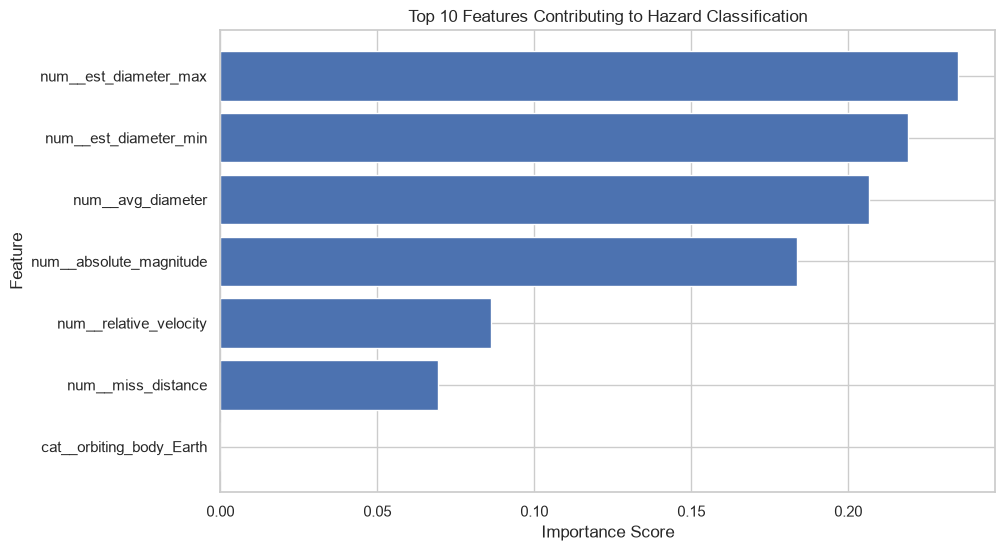

,feature,importance
1,num__est_diameter_max,0.235105
0,num__est_diameter_min,0.218900
5,num__avg_diameter,0.206753
4,num__absolute_magnitude,0.183747
2,num__relative_velocity,0.086081
3,num__miss_distance,0.069414
6,cat__orbiting_body_Earth,0.000000


In [8]:
final_model_name = 'Random Forest'
final_model = models[final_model_name]

feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_model.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Top 10 Features Contributing to Hazard Classification')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

importance_df


In [9]:
logistic_pipeline = models['Logistic Regression']
coef = logistic_pipeline.named_steps['model'].coef_[0]
logit_terms = pd.DataFrame({
    'feature': logistic_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    'abs_coefficient': abs(coef)
})
logit_terms = logit_terms.sort_values('abs_coefficient', ascending=False).head(10)
logit_terms


,feature,abs_coefficient
4,num__absolute_magnitude,3.740837
6,cat__orbiting_body_Earth,1.092354
0,num__est_diameter_min,0.498042
5,num__avg_diameter,0.498042
1,num__est_diameter_max,0.498042
3,num__miss_distance,0.356458
2,num__relative_velocity,0.240855


## Phase 6: Deployment

Save the trained model and provide a small prediction function that can classify future asteroid observations.


In [10]:
joblib.dump(final_model, 'hazardous_asteroid_model.pkl')
print('Final model saved to hazardous_asteroid_model.pkl')


Final model saved to hazardous_asteroid_model.pkl


In [11]:
def predict_hazardous(absolute_magnitude, est_diameter_min, est_diameter_max, relative_velocity, miss_distance, orbiting_body='Earth', sentry_object=False):
    row = pd.DataFrame([{
        'absolute_magnitude': absolute_magnitude,
        'est_diameter_min': est_diameter_min,
        'est_diameter_max': est_diameter_max,
        'relative_velocity': relative_velocity,
        'miss_distance': miss_distance,
        'orbiting_body': orbiting_body,
        'sentry_object': sentry_object,
        'avg_diameter': (est_diameter_min + est_diameter_max) / 2,
    }])

    prediction = final_model.predict(row[X.columns])[0]
    probability = final_model.predict_proba(row[X.columns])[0, 1]
    label = 'Hazardous' if prediction == 1 else 'Non-Hazardous'
    return label, round(probability, 4)

example_result = predict_hazardous(
    absolute_magnitude=21.0,
    est_diameter_min=0.35,
    est_diameter_max=0.78,
    relative_velocity=45000,
    miss_distance=20000000,
    orbiting_body='Earth',
    sentry_object=False,
)
print('Example prediction:', example_result)


Example prediction: ('Hazardous', np.float64(0.7169))
